<a href="https://colab.research.google.com/github/Gabriel-idkw/Face-Recognition-AI-Model/blob/main/Face_Recognition_Project_Finalize.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Install dependencies

#Install all required Python libraries for face recognition, machine learning, plotting, and model saving.


In [ ]:
!pip install -q deepface scikit-learn matplotlib pandas joblib opencv-python-headless==4.10.0.84


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.7 MB/s eta 0:00:00


#Check that OpenCV is installed correctly and that the required face-detection component is available.


In [ ]:
import cv2

print("OpenCV version:", cv2.__version__)
print(
    "CascadeClassifier available:",
    hasattr(cv2, "CascadeClassifier")
)

OpenCV version: 4.10.0
CascadeClassifier available: True


#Mount Google Drive so the notebook can access the stored face dataset.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Locate the face dataset, identify each person folder, and count the images for every person.


In [ ]:
import os

FACES_ROOT = "/content/drive/MyDrive/Dataset/Faces"

def find_faces_dir(root):
    """Find the folder that directly contains one subfolder per person.
    Looks for a folder literally named 'Faces'; falls back to the first
    directory that contains only subdirectories."""
    for dirpath, dirnames, filenames in os.walk(root):
        if os.path.basename(dirpath).lower() == "faces":
            return dirpath
    for dirpath, dirnames, filenames in os.walk(root):
        if dirnames and not filenames:
            return dirpath
    return root

FACES_DIR = find_faces_dir(FACES_ROOT)
print("Using person folders from:", FACES_DIR)

people = sorted(d for d in os.listdir(FACES_DIR) if os.path.isdir(os.path.join(FACES_DIR, d)))
print(f"\n{len(people)} people found:")
for p in people:
    n = len([f for f in os.listdir(os.path.join(FACES_DIR, p))
             if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    print(f"  {p}: {n} images")


Using person folders from: /content/drive/MyDrive/Dataset/Faces

31 people found:
  Akshay Kumar: 49 images
  Alexandra Daddario: 49 images
  Alia Bhatt: 49 images
  Amitabh Bachchan: 49 images
  Andy Samberg: 49 images
  Anushka Sharma: 49 images
  Billie Eilish: 49 images
  Brad Pitt: 49 images
  Camila Cabello: 49 images
  Charlize Theron: 49 images
  Claire Holt: 49 images
  Courtney Cox: 49 images
  Dwayne Johnson: 49 images
  Elizabeth Olsen: 49 images
  Ellen Degeneres: 49 images
  Henry Cavill: 49 images
  Hrithik Roshan: 49 images
  Hugh Jackman: 49 images
  Jessica Alba: 49 images
  Kashyap: 30 images
  Lisa Kudrow: 49 images
  Margot Robbie: 49 images
  Marmik: 32 images
  Natalie Portman: 49 images
  Priyanka Chopra: 49 images
  Robert Downey Jr: 49 images
  Roger Federer: 49 images
  Tom Cruise: 49 images
  Vijay Deverakonda: 49 images
  Virat Kohli: 49 images
  Zac Efron: 49 images


#Calculate basic dataset statistics such as total people, total images, and images per person.


In [ ]:
import matplotlib.pyplot as plt

person_counts = {}

for person in people:
    person_dir = os.path.join(FACES_DIR, person)

    images = [
        f for f in os.listdir(person_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    person_counts[person] = len(images)

print("Total people:", len(person_counts))
print("Total images:", sum(person_counts.values()))
print("Minimum images per person:", min(person_counts.values()))
print("Maximum images per person:", max(person_counts.values()))
print("Average images per person:",
      sum(person_counts.values()) / len(person_counts))

Total people: 31
Total images: 1483
Minimum images per person: 30
Maximum images per person: 49
Average images per person: 47.83870967741935


#Visualize how the images are distributed across the different people in the dataset.


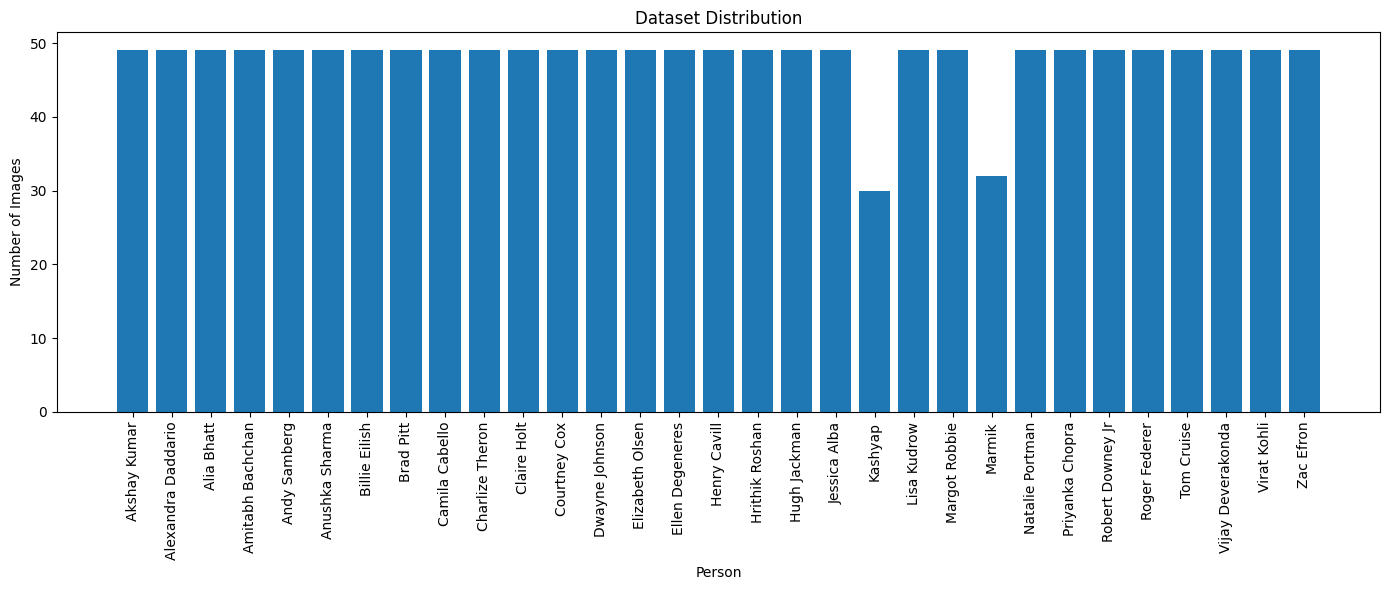

In [ ]:
plt.figure(figsize=(14, 6))

plt.bar(
    person_counts.keys(),
    person_counts.values()
)

plt.xticks(rotation=90)
plt.xlabel("Person")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")

plt.tight_layout()
plt.show()

## 3. Create Reference, Validation, and Test Splits

To avoid using the test set during threshold optimization, the dataset is divided into three subsets for each person:

- 70% Reference set — used to build the face-embedding database.
- 15% Validation set — used to optimize the recognition threshold.
- 15% Test set — used only for final evaluation.

The test set remains unseen during threshold optimization.



#Split each person's images into Reference, Validation, and Test sets using a fixed random seed.


In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

reference_files, reference_labels = [], []
validation_files, validation_labels = [], []
test_files, test_labels = [], []

for person in people:

    person_dir = os.path.join(FACES_DIR, person)

    images = [
        os.path.join(person_dir, f)
        for f in os.listdir(person_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if len(images) < 3:
        print(f"Skipping {person}: not enough images")
        continue

    # 70% reference, 30% temporary
    ref, temp = train_test_split(
        images,
        test_size=0.30,
        random_state=RANDOM_SEED
    )

    # Split temporary 30% into 15% validation and 15% test
    val, test = train_test_split(
        temp,
        test_size=0.50,
        random_state=RANDOM_SEED
    )

    reference_files.extend(ref)
    reference_labels.extend([person] * len(ref))

    validation_files.extend(val)
    validation_labels.extend([person] * len(val))

    test_files.extend(test)
    test_labels.extend([person] * len(test))


print(
    f"Reference: {len(reference_files)} images "
    f"across {len(set(reference_labels))} people"
)

print(
    f"Validation: {len(validation_files)} images "
    f"across {len(set(validation_labels))} people"
)

print(
    f"Test: {len(test_files)} images "
    f"across {len(set(test_labels))} people"
)

Reference: 1029 images across 31 people
Validation: 212 images across 31 people
Test: 242 images across 31 people


# ✅ DONE — Visualize and display the number and percentage of images in each dataset split.


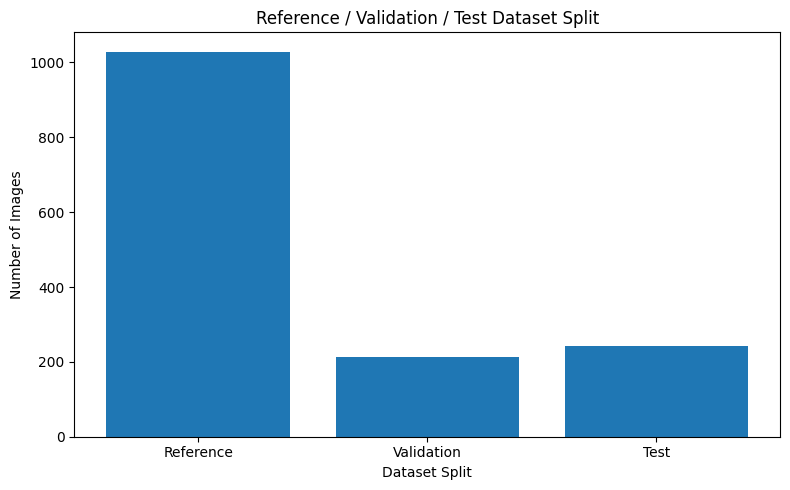

Reference: 1029 images (69.4%)
Validation: 212 images (14.3%)
Test: 242 images (16.3%)


In [ ]:
import matplotlib.pyplot as plt

split_counts = {
    "Reference": len(reference_files),
    "Validation": len(validation_files),
    "Test": len(test_files)
}

plt.figure(figsize=(8, 5))

plt.bar(
    split_counts.keys(),
    split_counts.values()
)

plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.title("Reference / Validation / Test Dataset Split")

plt.tight_layout()
plt.show()

print(
    f"Reference: {len(reference_files)} images "
    f"({len(reference_files) / (len(reference_files) + len(validation_files) + len(test_files)) * 100:.1f}%)"
)

print(
    f"Validation: {len(validation_files)} images "
    f"({len(validation_files) / (len(reference_files) + len(validation_files) + len(test_files)) * 100:.1f}%)"
)

print(
    f"Test: {len(test_files)} images "
    f"({len(test_files) / (len(reference_files) + len(validation_files) + len(test_files)) * 100:.1f}%)"
)

## 4. Build the reference embeddings (Stages 1–3: Detect → Align → Embed)

`DeepFace.represent()` handles face detection, alignment, and embedding
extraction in one call using a pre-trained backbone.


#Generate ArcFace embeddings from the reference images to create the face recognition database.


In [ ]:
from deepface import DeepFace
import numpy as np

MODEL_NAME = "ArcFace"

def build_embeddings(
    file_list,
    label_list,
    model_name=MODEL_NAME
):

    embeddings, labels = [], []

    for fpath, label in zip(file_list, label_list):
        try:
            reps = DeepFace.represent(
                img_path=fpath,
                model_name=model_name,
                enforce_detection=False
            )

            for rep in reps:
                embeddings.append(rep["embedding"])
                labels.append(label)
        except Exception as e:
            print(f"Skipping {fpath}: {e}")

    return np.array(embeddings), labels


ref_embeddings, ref_labels = build_embeddings(
    reference_files,
    reference_labels
)

print(
    f"Built {len(ref_labels)} reference embeddings "
    f"for {len(set(ref_labels))} people"
)


26-08-15 17:22:28 - Directory /root/.deepface has been created
26-08-15 17:22:28 - Directory /root/.deepface/weights has been created
26-08-15 17:22:31 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to /root/.deepface/weights/arcface_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5
100%|██████████| 137M/137M [00:00<00:00, 172MB/s]


Built 1030 reference embeddings for 31 people


#Recognize a face by comparing its embedding with reference embeddings using cosine distance.


In [ ]:
#5.Recognition
from scipy.spatial.distance import cosine
from numpy.linalg import norm


def cosine_distance(a, b):

    denominator = norm(a) * norm(b)

    if denominator == 0:
        return 1.0

    return 1 - (
        np.dot(a, b) / denominator
    )


def recognize(
    img_path,
    ref_embeddings,
    ref_labels,
    threshold=0.40,
    model_name=MODEL_NAME
):

    try:

        reps = DeepFace.represent(
            img_path=img_path,
            model_name=model_name,
            enforce_detection=False
        )

        if not reps:
            return "No Face", None
        query_emb = np.array(
            reps[0]["embedding"]
        )

    except Exception:
        return "No Face", None


    distances = [
        cosine_distance(
            query_emb,
            ref_emb
        )
        for ref_emb in ref_embeddings
    ]


    if not distances:
        return "Unknown", None

    best_idx = int(
        np.argmin(distances)
    )

    best_distance = distances[best_idx]


    if best_distance < threshold:
        return (
            ref_labels[best_idx],
            best_distance
        )


    return "Unknown", best_distance

# Test different recognition thresholds on the validation set and select the threshold with the best Macro F1.


In [ ]:
#6. Optimize Recognition Threshold
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

thresholds = np.arange(0.20, 0.61, 0.01)

threshold_results = []

for threshold in thresholds:

    y_val_true = []
    y_val_pred = []

    for fpath, true_label in zip(
        validation_files,
        validation_labels
    ):

        pred_label, distance = recognize(
            fpath,
            ref_embeddings,
            ref_labels,
            threshold=threshold
        )

        y_val_true.append(true_label)
        y_val_pred.append(pred_label)

    accuracy = accuracy_score(
        y_val_true,
        y_val_pred
    )

    macro_f1 = f1_score(
        y_val_true,
        y_val_pred,
        average="macro",
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    })


best_result = max(
    threshold_results,
    key=lambda x: x["macro_f1"]
)

BEST_THRESHOLD = best_result["threshold"]

print(f"Best threshold: {BEST_THRESHOLD:.2f}")
print(f"Validation accuracy: {best_result['accuracy']:.4f}")
print(f"Validation Macro F1: {best_result['macro_f1']:.4f}")

Best threshold: 0.58
Validation accuracy: 0.9623
Validation Macro F1: 0.9598


#Plot Accuracy and Macro F1 across thresholds to visualize the threshold optimization.


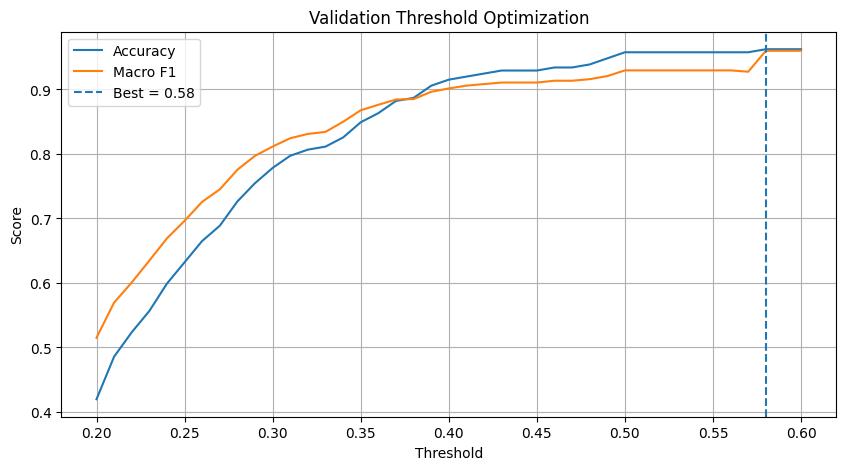

In [ ]:
#7.Optimize Recognition Threshold graph
import pandas as pd
import matplotlib.pyplot as plt

threshold_df = pd.DataFrame(threshold_results)

plt.figure(figsize=(10, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["accuracy"],
    label="Accuracy"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["macro_f1"],
    label="Macro F1"
)

plt.axvline(
    BEST_THRESHOLD,
    linestyle="--",
    label=f"Best = {BEST_THRESHOLD:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Validation Threshold Optimization")
plt.legend()
plt.grid(True)

plt.show()

## 6. Evaluate on the held-out test photos (Stage 5: Evaluate & Document)

Accuracy, per-person precision/recall/F1, and a confusion matrix — the
metrics your teacher wants to see documented.


#Evaluate the final face recognition system on the unseen test set using classification metrics and a confusion matrix.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

y_true = []
y_pred = []
y_distances = []

for fpath, true_label in zip(test_files, test_labels):

    pred_label, dist = recognize(
        fpath,
        ref_embeddings,
        ref_labels,
        threshold=BEST_THRESHOLD
    )

    y_true.append(true_label)
    y_pred.append(pred_label)
    y_distances.append(dist)


print(f"Evaluated on {len(y_true)} test images\n")

print("Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        zero_division=0
    )
)


# Confusion Matrix
labels_sorted = sorted(set(y_true) | set(y_pred))

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels_sorted
)

cm_df = pd.DataFrame(
    cm,
    index=labels_sorted,
    columns=labels_sorted
)

print("\nConfusion Matrix")
print("(Rows = Actual, Columns = Predicted)")

display(cm_df)


Evaluated on 242 test images

Classification Report:
                    precision    recall  f1-score   support

      Akshay Kumar       1.00      0.75      0.86         8
Alexandra Daddario       1.00      1.00      1.00         8
        Alia Bhatt       0.80      1.00      0.89         8
  Amitabh Bachchan       0.89      1.00      0.94         8
      Andy Samberg       1.00      1.00      1.00         8
    Anushka Sharma       1.00      0.88      0.93         8
     Billie Eilish       0.86      0.75      0.80         8
         Brad Pitt       1.00      1.00      1.00         8
    Camila Cabello       1.00      0.88      0.93         8
   Charlize Theron       1.00      1.00      1.00         8
       Claire Holt       0.89      1.00      0.94         8
      Courtney Cox       1.00      0.88      0.93         8
    Dwayne Johnson       1.00      0.88      0.93         8
   Elizabeth Olsen       1.00      0.88      0.93         8
   Ellen Degeneres       1.00      1.00      1

,Akshay Kumar,Alexandra Daddario,Alia Bhatt,Amitabh Bachchan,Andy Samberg,Anushka Sharma,Billie Eilish,Brad Pitt,Camila Cabello,Charlize Theron,...,Marmik,Natalie Portman,Priyanka Chopra,Robert Downey Jr,Roger Federer,Tom Cruise,Unknown,Vijay Deverakonda,Virat Kohli,Zac Efron
Akshay Kumar,6,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alexandra Daddario,0,8,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alia Bhatt,0,0,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Amitabh Bachchan,0,0,0,8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Andy Samberg,0,0,0,0,8,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Anushka Sharma,0,0,0,0,0,7,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
Billie Eilish,0,0,1,0,0,0,6,0,0,0,...,0,0,1,0,0,0,0,0,0,0
Brad Pitt,0,0,0,0,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
Camila Cabello,0,0,0,0,0,0,0,0,7,0,...,0,0,0,0,0,0,0,0,0,0
Charlize Theron,0,0,0,0,0,0,0,0,0,8,...,0,0,0,0,0,0,0,0,0,0


#Find and display the test images that were incorrectly recognized.


In [ ]:
errors = []

for fpath, true_label, pred_label in zip(
    test_files,
    y_true,
    y_pred
):

    if true_label != pred_label:

        errors.append({
            "image": fpath,
            "actual": true_label,
            "predicted": pred_label
        })

errors_df = pd.DataFrame(errors)

print("Total incorrect predictions:", len(errors_df))

display(errors_df)

Total incorrect predictions: 14


,image,actual,predicted
0,/content/drive/MyDrive/Dataset/Faces/Akshay Ku...,Akshay Kumar,Billie Eilish
1,/content/drive/MyDrive/Dataset/Faces/Akshay Ku...,Akshay Kumar,Hrithik Roshan
2,/content/drive/MyDrive/Dataset/Faces/Anushka S...,Anushka Sharma,Priyanka Chopra
3,/content/drive/MyDrive/Dataset/Faces/Billie Ei...,Billie Eilish,Priyanka Chopra
4,/content/drive/MyDrive/Dataset/Faces/Billie Ei...,Billie Eilish,Alia Bhatt
5,/content/drive/MyDrive/Dataset/Faces/Camila Ca...,Camila Cabello,Kashyap
6,/content/drive/MyDrive/Dataset/Faces/Courtney ...,Courtney Cox,Alia Bhatt
7,/content/drive/MyDrive/Dataset/Faces/Dwayne Jo...,Dwayne Johnson,Hugh Jackman
8,/content/drive/MyDrive/Dataset/Faces/Elizabeth...,Elizabeth Olsen,Unknown
9,/content/drive/MyDrive/Dataset/Faces/Hrithik R...,Hrithik Roshan,Virat Kohli


## 7. Visualize a few predictions

#Display several random test images with their true label, predicted label, and recognition distance.


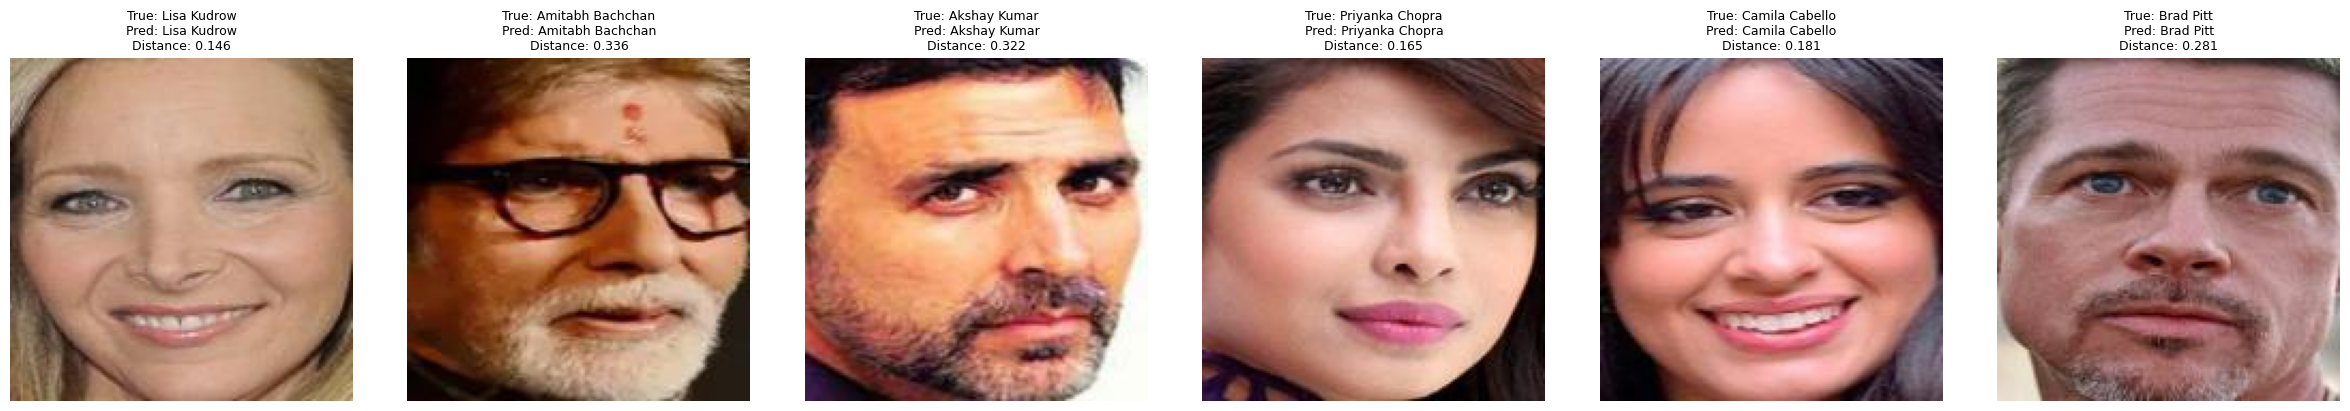

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random

random.seed(RANDOM_SEED)

# Select 6 random test images
sample_pairs = random.sample(
    list(zip(test_files, test_labels)),
    k=min(6, len(test_files))
)

n = len(sample_pairs)
fig, axes = plt.subplots(
    1,
    n,
    figsize=(4 * n, 4)
)

if n == 1:
    axes = [axes]
for ax, (fpath, true_label) in zip(
    axes,
    sample_pairs
):

    # Use the optimized threshold
    pred_label, dist = recognize(
        fpath,
        ref_embeddings,
        ref_labels,
        threshold=BEST_THRESHOLD
    )

    img = cv2.imread(fpath)
    if img is None:
        ax.set_title("Image could not be loaded")
        ax.axis("off")
        continue

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(img)
    correct = pred_label == true_label
    dist_txt = (
        f"{dist:.3f}"
        if dist is not None
        else "n/a"
    )

    ax.set_title(
        f"True: {true_label}\n"
        f"Pred: {pred_label}\n"
        f"Distance: {dist_txt}",
        fontsize=9
    )

    ax.axis("off")

plt.tight_layout()
plt.show()


#8. Compare pre-trained backbones

Benchmarking more than one pre-trained model gives you real experimentation
to discuss — which backbone was more accurate, and which was faster.


#Compare Facenet, ArcFace, and VGG-Face by optimizing their thresholds and measuring test performance and runtime.


In [ ]:
import time
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

MODEL_LIST = ["Facenet", "ArcFace", "VGG-Face"]

comparison = {}

thresholds = np.arange(0.20, 0.61, 0.01)


for model_name in MODEL_LIST:

    print(f"\n========== {model_name} ==========")

    start = time.time()

    # ------------------------------------------------
    # 1. Build reference embeddings ONCE
    # ------------------------------------------------

    embs, labs = build_embeddings(
        reference_files,
        reference_labels,
        model_name=model_name
    )

    print(f"Reference embeddings: {len(labs)}")


    # ------------------------------------------------
    # 2. Calculate validation distances ONCE
    # ------------------------------------------------

    val_results = []

    for fpath, true_label in zip(
        validation_files,
        validation_labels
    ):

        # Use a neutral threshold so we can get the
        # closest prediction and its distance.
        pred, dist = recognize(
            fpath,
            embs,
            labs,
            model_name=model_name,
            threshold=999
        )

        val_results.append(
            (true_label, pred, dist)
        )


    # ------------------------------------------------
    # 3. Find best threshold
    #    No DeepFace inference here
    # ------------------------------------------------

    best_threshold = 0.40
    best_f1 = -1

    for threshold in thresholds:

        val_true = []
        val_pred = []

        for true_label, pred, dist in val_results:

            # Apply threshold manually
            if dist is not None and dist <= threshold:
                final_pred = pred
            else:
                final_pred = "unknown"

            val_true.append(true_label)
            val_pred.append(final_pred)


        score = f1_score(
            val_true,
            val_pred,
            average="macro",
            zero_division=0
        )


        if score > best_f1:

            best_f1 = score
            best_threshold = threshold


    print(
        f"Best threshold: {best_threshold:.2f}"
    )

    print(
        f"Validation Macro F1: {best_f1:.3f}"
    )


    # ------------------------------------------------
    # 4. Calculate TEST distances ONCE
    # ------------------------------------------------

    test_results = []

    for fpath, true_label in zip(
        test_files,
        test_labels
    ):

        pred, dist = recognize(
            fpath,
            embs,
            labs,
            model_name=model_name,
            threshold=999
        )

        test_results.append(
            (true_label, pred, dist)
        )


    # ------------------------------------------------
    # 5. Apply optimized threshold to test set
    # ------------------------------------------------

    test_true = []
    test_pred = []

    for true_label, pred, dist in test_results:

        if dist is not None and dist <= best_threshold:
            final_pred = pred
        else:
            final_pred = "unknown"

        test_true.append(true_label)
        test_pred.append(final_pred)


    # ------------------------------------------------
    # 6. Calculate test metrics
    # ------------------------------------------------

    accuracy = accuracy_score(
        test_true,
        test_pred
    )

    precision = precision_score(
        test_true,
        test_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        test_true,
        test_pred,
        average="macro",
        zero_division=0
    )

    test_f1 = f1_score(
        test_true,
        test_pred,
        average="macro",
        zero_division=0
    )


    # ------------------------------------------------
    # 7. Save results
    # ------------------------------------------------

    elapsed = time.time() - start

    comparison[model_name] = {

        "Best Threshold":
            round(best_threshold, 2),

        "Validation Macro F1":
            round(best_f1, 3),

        "Test Accuracy":
            round(accuracy, 3),

        "Test Precision":
            round(precision, 3),

        "Test Recall":
            round(recall, 3),

        "Test Macro F1":
            round(test_f1, 3),

        "Time (seconds)":
            round(elapsed, 1)
    }


# ----------------------------------------------------
# 8. Final comparison table
# ----------------------------------------------------

comparison_df = pd.DataFrame(
    comparison
).T

display(comparison_df)


========== Facenet ==========
26-08-15 18:00:54 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to /root/.deepface/weights/facenet_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5
100%|██████████| 92.2M/92.2M [00:00<00:00, 167MB/s]


Reference embeddings: 1030
Best threshold: 0.42
Validation Macro F1: 0.972

========== ArcFace ==========
Reference embeddings: 1030
Best threshold: 0.58
Validation Macro F1: 0.960

========== VGG-Face ==========
26-08-15 18:11:56 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to /root/.deepface/weights/vgg_face_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5
100%|██████████| 580M/580M [00:06<00:00, 88.0MB/s]


Reference embeddings: 1030
Best threshold: 0.59
Validation Macro F1: 0.976


,Best Threshold,Validation Macro F1,Test Accuracy,Test Precision,Test Recall,Test Macro F1,Time (seconds)
Facenet,0.42,0.972,0.938,0.932,0.908,0.915,430.6
ArcFace,0.58,0.960,0.942,0.923,0.909,0.912,233.7
VGG-Face,0.59,0.976,0.934,0.926,0.906,0.912,133.8


#Visualize the test Accuracy, Precision, Recall, and Macro F1 for each face recognition model.


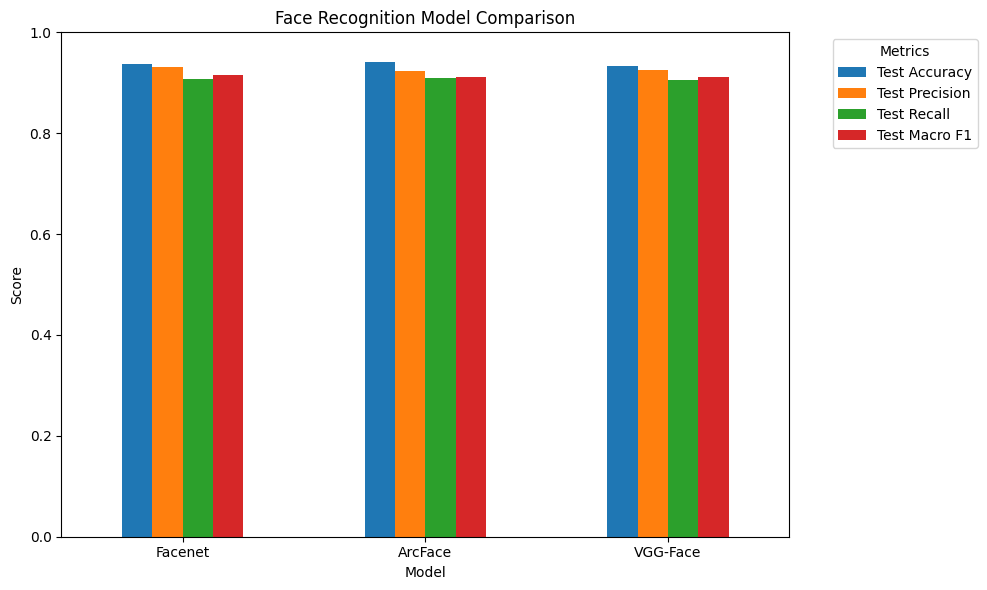

In [ ]:
#Model Comparison Visualization
import matplotlib.pyplot as plt

# Select metrics for visualization
metrics = [
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test Macro F1"
]

comparison_df[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Face Recognition Model Comparison")
plt.ylim(0, 1)

plt.xticks(
    range(len(comparison_df)),
    comparison_df.index,
    rotation=0
)

plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

#Select the best model based on Test Macro F1 and display its key results.


In [ ]:
# Find the best model based on Test Macro F1
best_model = comparison_df["Test Macro F1"].idxmax()

best_threshold = comparison_df.loc[
    best_model,
    "Best Threshold"
]

best_validation_f1 = comparison_df.loc[
    best_model,
    "Validation Macro F1"
]

best_test_f1 = comparison_df.loc[
    best_model,
    "Test Macro F1"
]

best_accuracy = comparison_df.loc[
    best_model,
    "Test Accuracy"
]


print("========== Best Model ==========")
print(f"Model: {best_model}")
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Validation Macro F1: {best_validation_f1:.3f}")
print(f"Test Accuracy: {best_accuracy:.3f}")
print(f"Test Macro F1: {best_test_f1:.3f}")

========== Best Model ==========
Model: Facenet
Best Threshold: 0.42
Validation Macro F1: 0.972
Test Accuracy: 0.938
Test Macro F1: 0.915


## 9.Try it on a photo from your own computer

# Upload a new image from the computer and run face recognition using the selected model and threshold.


In [ ]:
from google.colab import files as files2

uploaded2 = files2.upload()

for fname in uploaded2.keys():
    pred_label, dist = recognize(
        fname,
        ref_embeddings,
        ref_labels,
        threshold=BEST_THRESHOLD
    )

    dist_txt = f"{dist:.3f}" if dist is not None else "n/a"

    print(
        f"{fname}: predicted = {pred_label} "
        f"(distance = {dist_txt})"
    )

#Save the trained reference embeddings, labels, model name, and threshold into a reusable Joblib file.


In [ ]:
import joblib

model_data = {
    "model_name": MODEL_NAME,
    "threshold": BEST_THRESHOLD,
    "ref_embeddings": ref_embeddings,
    "ref_labels": ref_labels
}

joblib.dump(
    model_data,
    "face_recognition_model.joblib"
)

print("Model saved successfully.")

Model saved successfully.
